## Preprocessing 

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import matplotlib 

In [2]:
df_load = pd.read_csv("/Users/arpitalonakadi/Documents/GIT Final folders/Petrol price/PET_PRI_GND_DCUS_NUS_W.csv")
df_load.head()

,Date,A1,A2,A3,R1,R2,R3,M1,M2,M3,P1,P2,P3,D1
0,01/02/1995,1.127,1.104,1.231,1.079,1.063,1.167,1.170,1.159,1.298,1.272,1.250,1.386,1.104
1,01/09/1995,1.134,1.111,1.232,1.086,1.070,1.169,1.177,1.164,1.300,1.279,1.256,1.387,1.102
2,01/16/1995,1.126,1.102,1.231,1.078,1.062,1.169,1.168,1.155,1.299,1.271,1.249,1.385,1.100
3,01/23/1995,1.132,1.110,1.226,1.083,1.068,1.165,1.177,1.165,1.296,1.277,1.256,1.378,1.095
4,01/30/1995,1.131,1.109,1.221,1.083,1.068,1.162,1.176,1.163,1.291,1.275,1.255,1.370,1.090


In [3]:
#Creating first copy of loaded dataset 
df1 = df_load

<Axes: >

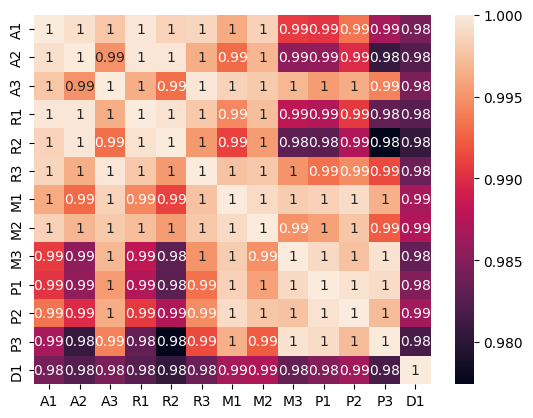

In [4]:
import seaborn as sns
df_load = df_load.drop(['Date'], axis=1)
sns.heatmap(df_load.corr(), annot=True)

In [5]:
df_filtered = df1[['Date', 'A1', 'R1', 'D1']]

In [6]:

df_filtered.isnull().sum()

Date    0
A1      0
R1      0
D1      0
dtype: int64

In [7]:
df_filtered = df_filtered.dropna()

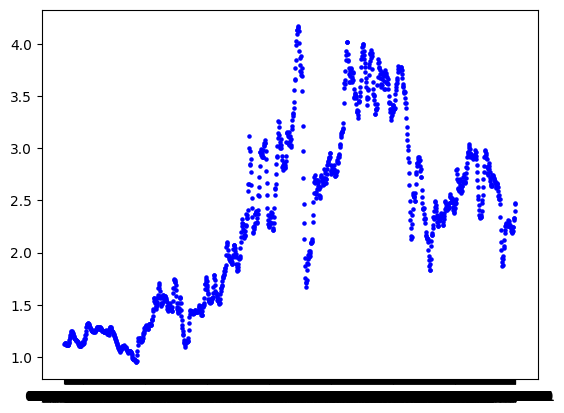

In [8]:
plt.scatter(df_filtered.Date, df_filtered.A1,color='BLUE',label='Prices', s=5)

In [9]:
#Creating a replica of the dataset as a checkpoint in case of any future issues :
df = df_filtered

In [10]:
import pandas as pd

# Assuming df is your main DataFrame
Q1 = df['A1'].quantile(0.25)
Q3 = df['A1'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers
outliers = df[(df['A1'] < lower_bound) | (df['A1'] > upper_bound)]

print("Number of outliers in A1:", len(outliers))

Number of outliers in A1: 0


In [11]:
import pandas as pd

# Assuming df is your main DataFrame
Q1 = df['R1'].quantile(0.25)
Q3 = df['R1'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers
outliers = df[(df['R1'] < lower_bound) | (df['R1'] > upper_bound)]

print("Number of outliers in R1:", len(outliers))

Number of outliers in R1: 0


In [12]:
import pandas as pd

# Assuming df is your main DataFrame
Q1 = df['D1'].quantile(0.25)
Q3 = df['D1'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers
outliers = df[(df['D1'] < lower_bound) | (df['D1'] > upper_bound)]

print("Number of outliers in D1:", len(outliers))

Number of outliers in D1: 0


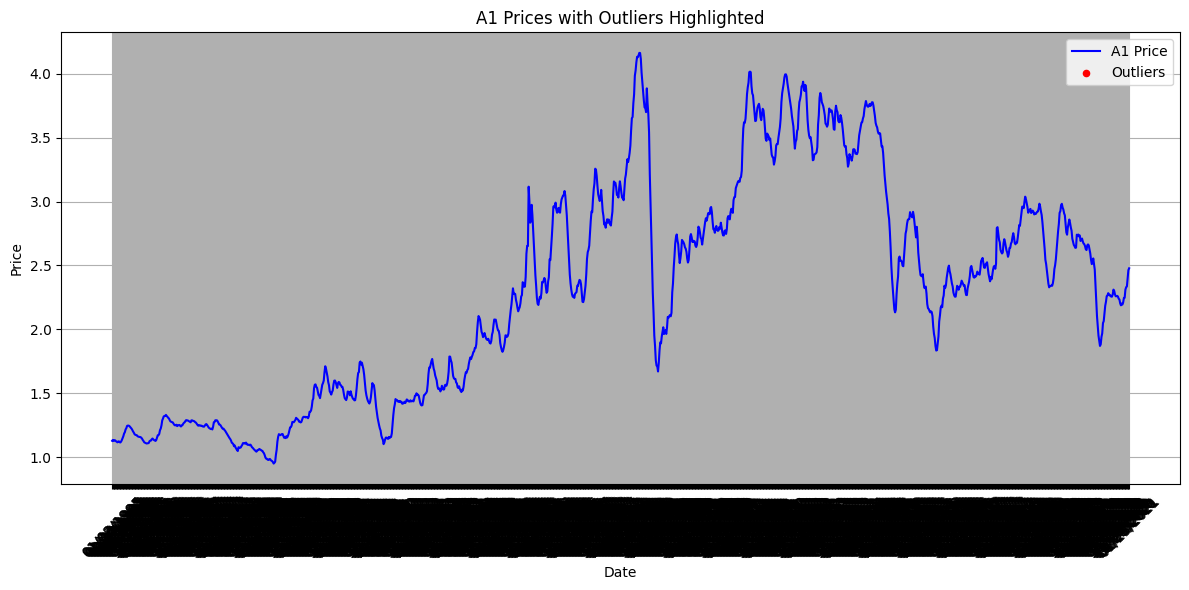

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Line plot for all A1 values
plt.plot(df['Date'], df['A1'], label='A1 Price', color='blue')

# Scatter plot for detected outliers
plt.scatter(outliers['Date'], outliers['A1'], color='red', label='Outliers', s=20)

plt.title('A1 Prices with Outliers Highlighted')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
scalers = {}
scaled_columns = []

for col in ['A1', 'R1', 'D1']:
    s = MinMaxScaler()
    scaled = s.fit_transform(df[[col]])
    scaled_columns.append(scaled)
    scalers[col] = s

scaled_data = np.hstack(scaled_columns)
scaled_df = pd.DataFrame(scaled_data, columns=['A1', 'R1', 'D1'])

In [15]:
# Convert to NumPy array
data = scaled_df.values

# Calculate training size
training_size = int(len(data) * 0.75)
test_size = len(data) - training_size

# Split
train_data = data[0:training_size, :]
test_data = data[training_size:, :]

In [16]:
train_data.shape

(1020, 3)

In [17]:
test_data.shape

(341, 3)

In [18]:
import numpy as np

def create_multivariate_dataset(dataset, time_step=100):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step):
        dataX.append(dataset[i:i + time_step])      # shape: (time_step, 3)
        dataY.append(dataset[i + time_step])         # shape: (3,)
    return np.array(dataX), np.array(dataY)

time_step = 100

X_train, y_train = create_multivariate_dataset(train_data, time_step)
X_test, y_test = create_multivariate_dataset(test_data, time_step)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (920, 100, 3)
y_train shape: (920, 3)


In [ ]:
import joblib
import numpy as np
import os

# Create a folder if it doesn't exist
os.makedirs("preprocessed_data", exist_ok=True)

# Save datasets
np.save("preprocessed_data/X_train.npy", X_train)
np.save("preprocessed_data/y_train.npy", y_train)
np.save("preprocessed_data/X_test.npy", X_test)
np.save("preprocessed_data/y_test.npy", y_test)

# Save scalers dictionary (used to inverse transform each column)
joblib.dump(scalers, "preprocessed_data/scalers.pkl")

print(" Datasets and scalers saved.")

✅ Datasets and scalers saved.


## LSTM Model build 

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Bidirectional

model = Sequential()
model.add(Bidirectional(LSTM(50, return_sequences=True), input_shape=(100, 3)))
model.add(Dropout(0.1))
model.add(Bidirectional(LSTM(50, return_sequences=True)))
model.add(Dropout(0.1))
model.add(Bidirectional(LSTM(50)))
model.add(Dense(3))

/Users/arpitalonakadi/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/arpitalonakadi/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',       # what to monitor
    patience=10,              # stop if no improvement after 10 epochs
    restore_best_weights=True  # roll back to best model weights
)

In [25]:
from tensorflow.keras.optimizers import Adam  # ← This line fixes the error
from tensorflow.keras.callbacks import EarlyStopping
# Compile
model.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=0.001))
# Fit model

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=64,
    verbose=1,
     callbacks=[early_stop]

)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0061 - val_loss: 0.0021
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 0.0021 - val_loss: 0.0011
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 0.0013 - val_loss: 7.7868e-04
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 9.1732e-04 - val_loss: 0.0010
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 9.7610e-04 - val_loss: 8.4129e-04
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 9.9561e-04 - val_loss: 7.8858e-04
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - loss: 7.8004e-04 - val_loss: 8.9787e-04
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - loss: 8.4462e-04 - val_loss: 9.7311e-04
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - loss: 7.6631e-04 - val_loss: 8.2721e-04
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - loss: 7.9566e-04 - val_loss: 8.0419e-04
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - loss: 7.0606e-04 - val

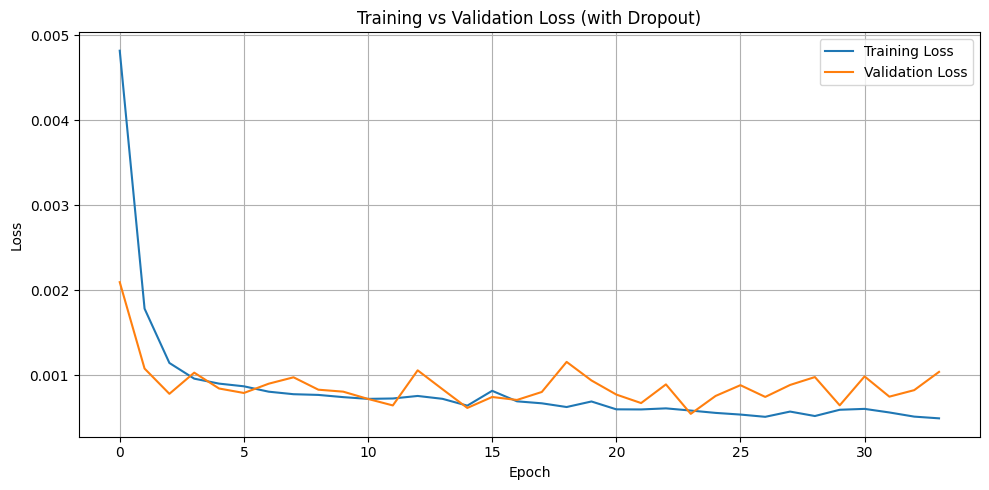

In [26]:
# Plot loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss (with Dropout)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
# Predict
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform each column separately using the saved scalers
train_predict_original = np.zeros_like(train_predict)
test_predict_original = np.zeros_like(test_predict)
y_train_original = np.zeros_like(y_train)
y_test_original = np.zeros_like(y_test)

for i, col in enumerate(['A1', 'R1', 'D1']):
    train_predict_original[:, i] = scalers[col].inverse_transform(train_predict[:, i].reshape(-1, 1)).ravel()
    test_predict_original[:, i] = scalers[col].inverse_transform(test_predict[:, i].reshape(-1, 1)).ravel()
    y_train_original[:, i] = scalers[col].inverse_transform(y_train[:, i].reshape(-1, 1)).ravel()
    y_test_original[:, i] = scalers[col].inverse_transform(y_test[:, i].reshape(-1, 1)).ravel()

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [28]:
from sklearn.metrics import mean_squared_error

def evaluate_predictions(true, pred, labels=['A1', 'R1', 'D1']):
    for i, label in enumerate(labels):
        rmse = np.sqrt(mean_squared_error(true[:, i], pred[:, i]))
        print(f'{label} RMSE: {rmse:.4f}')

print("Train RMSE:")
evaluate_predictions(y_train_original, train_predict_original)

print("\nTest RMSE:")
evaluate_predictions(y_test_original, test_predict_original)

Train RMSE:
A1 RMSE: 0.0752
R1 RMSE: 0.0773
D1 RMSE: 0.0696

Test RMSE:
A1 RMSE: 0.0776
R1 RMSE: 0.0824
D1 RMSE: 0.0750


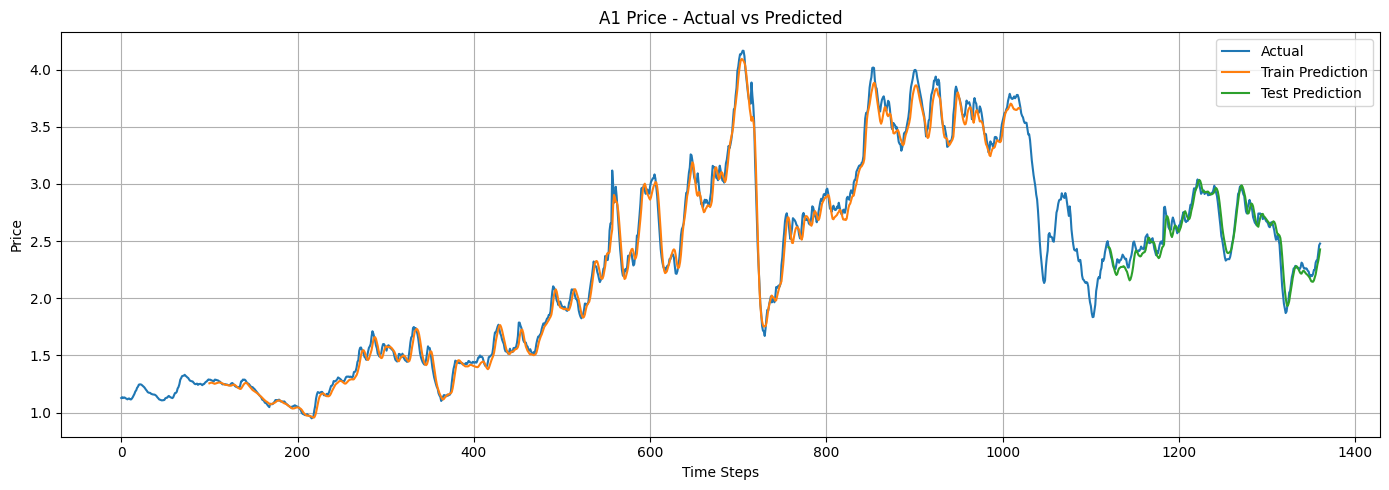

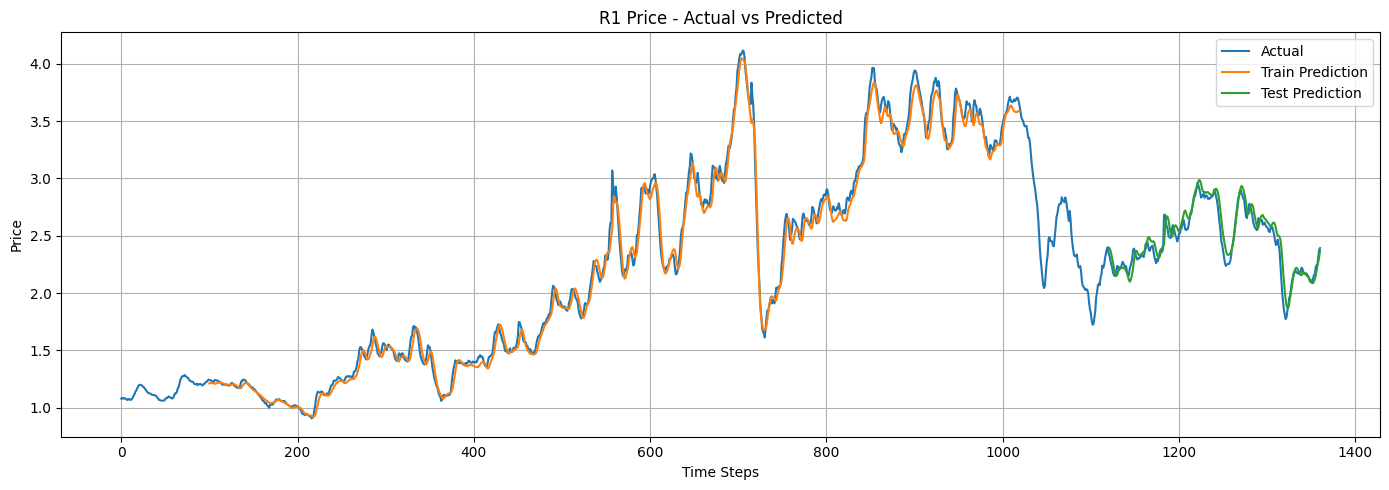

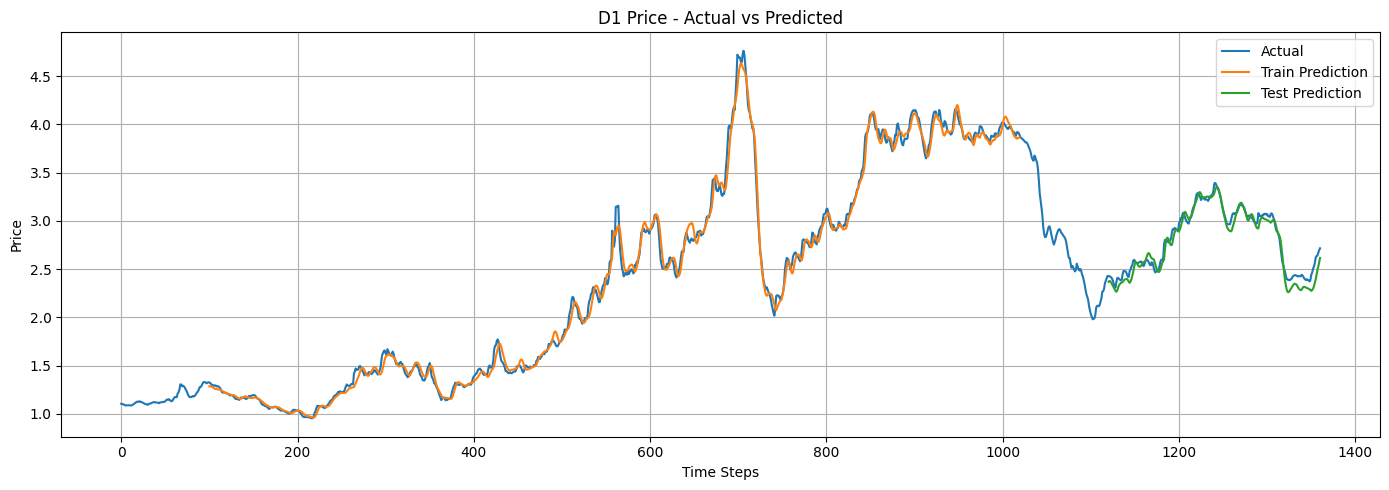

In [29]:
import matplotlib.pyplot as plt
import numpy as np

look_back = 100
full_len = len(scaled_df)

for i, label in enumerate(['A1', 'R1', 'D1']):
    plt.figure(figsize=(14, 5))

    # Inverse full series for that column
    actual_full = scalers[label].inverse_transform(scaled_df[label].values.reshape(-1, 1)).ravel()

    # Placeholder arrays
    train_plot = np.empty_like(actual_full)
    train_plot[:] = np.nan
    train_plot[look_back:len(train_predict)+look_back] = train_predict_original[:, i]

    test_plot = np.empty_like(actual_full)
    test_plot[:] = np.nan
    test_start = len(train_predict) + (look_back * 2)
    test_plot[test_start:test_start + len(test_predict)] = test_predict_original[:, i]

    # Plot
    plt.plot(actual_full, label='Actual')
    plt.plot(train_plot, label='Train Prediction')
    plt.plot(test_plot, label='Test Prediction')
    plt.title(f'{label} Price - Actual vs Predicted')
    plt.xlabel('Time Steps')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [30]:
model.save("models/lstm_model.keras")

## ARIMA MODEL

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")


# Reload the original dataset (assuming same CSV used earlier)
df = pd.read_csv("/Users/arpitalonakadi/Documents/GIT Final folders/Petrol price/PET_PRI_GND_DCUS_NUS_W.csv")  # <- Update with your file path
series = df['A1'].dropna().reset_index(drop=True)



In [32]:

# Train-test split
train_size = int(len(series) * 0.75)
train, test = series[:train_size], series[train_size:]

Rolling ARIMA RMSE: 0.0376


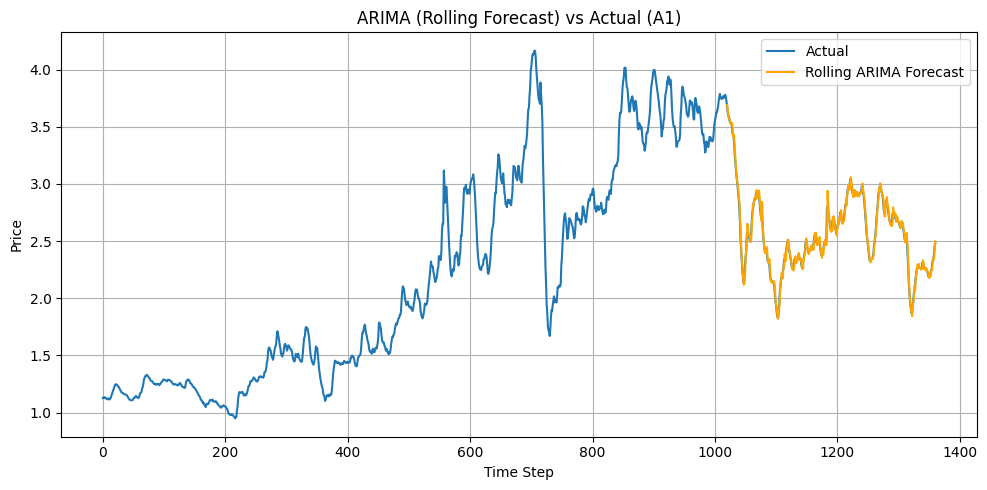

In [33]:
history = list(train)
predictions = []

for t in range(len(test)):
    model = ARIMA(history, order=(5,1,2))
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]
    predictions.append(yhat)
    history.append(test.iloc[t])

# Evaluate
rmse = np.sqrt(mean_squared_error(test, predictions))
print(f'Rolling ARIMA RMSE: {rmse:.4f}')

# Plot
plt.figure(figsize=(10, 5))
plt.plot(series.index, series, label='Actual')
plt.plot(test.index, predictions, label='Rolling ARIMA Forecast', color='orange')
plt.title('ARIMA (Rolling Forecast) vs Actual (A1)')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [44]:
import pickle

# Save the ARIMA model properly
with open("models/arima_model_A1.pkl", "wb") as f:
    pickle.dump(model_fit, f)

In [45]:
# Save rolling ARIMA predictions
np.save("models/arima_preds_A1.npy", np.array(predictions))

## AUTO ML - Keras based model build 

In [34]:
pip install autokeras

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import pandas as pd
import autokeras as ak
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error

# === Reshape data to 2D ===
X_train_ak = X_train.reshape((X_train.shape[0], -1))
X_test_ak = X_test.reshape((X_test.shape[0], -1))

# === Build and fit AutoKeras model (for A1 only) ===
input_node = ak.Input()
output_node = ak.RegressionHead(loss=MeanSquaredError())(input_node)

reg = ak.AutoModel(
    inputs=input_node,
    outputs=output_node,
    max_trials=3,
    overwrite=True
)

# Fit
reg.fit(x=X_train_ak, y=y_train[:, 0], epochs=50, verbose=1)

# Export and save the best model
best_model = reg.export_model()
best_model.save("auto_model/best_model.keras")

# Load the best model (useful for fresh notebooks/runs)
best_model = load_model("auto_model/best_model.keras", custom_objects=ak.CUSTOM_OBJECTS)

# Predict
yhat_train = best_model.predict(X_train_ak)
yhat_test = best_model.predict(X_test_ak)

# Inverse transform predictions (A1 only)
auto_preds_train_a1 = scalers['A1'].inverse_transform(yhat_train.reshape(-1, 1)).ravel()
auto_preds_test_a1 = scalers['A1'].inverse_transform(yhat_test.reshape(-1, 1)).ravel()

# Actual values (for comparison)
y_train_a1 = scalers['A1'].inverse_transform(y_train[:, 0].reshape(-1, 1)).ravel()
y_test_a1 = scalers['A1'].inverse_transform(y_test[:, 0].reshape(-1, 1)).ravel()

# Evaluate
print(" AutoKeras A1 Train RMSE:", np.sqrt(mean_squared_error(y_train_a1, auto_preds_train_a1)))
print(" AutoKeras A1 Test RMSE: ", np.sqrt(mean_squared_error(y_test_a1, auto_preds_test_a1)))

Trial 3 Complete [00h 00m 01s]
val_loss: 0.018347376957535744

Best val_loss So Far: 0.00280393217690289
Total elapsed time: 00h 00m 04s
Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 602us/step - loss: 0.0658 - mean_squared_error: 0.0658
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 551us/step - loss: 0.0519 - mean_squared_error: 0.0519
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 559us/step - loss: 0.0494 - mean_squared_error: 0.0494
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 508us/step - loss: 0.0426 - mean_squared_error: 0.0426
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 513us/step - loss: 0.0439 - mean_squared_error: 0.0439
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 512us/step - loss: 0.0464 - mean_squared_error: 0.0464
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 485us/step - loss: 0.0368 - mean_squared_error: 0.0368
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 523us/step - loss: 0.0340 - mean_squared_error: 0.0340
Epoch 9/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step - loss: 0.0395 - mean_squared_error: 0.0395